### Objective

* Test whether Chronos-2, a pre-trained forecasting model that has never seen ICU data, can predict patient physiology as well as the iTransformer trained in Notebook 08.
* Score Tier 2 on exactly the same test patients, the same windows, and the same metrics as Tier 1.
* Choose the Chronos-2 inference settings using only the validation set.
* Report MAE, RMSE and MASE against the same persistence baseline, and compare the two tiers honestly.

### 01. Setup and configuration

* Install the Chronos-2 package and import the libraries needed.
* Fix the random seed and select the device.
* Reuse the same paths, context length and horizons as Notebook 08.

In [3]:
!pip install "chronos-forecasting>=2.0" --quiet

AI-assisted: Claude Opus 4.8 assisted with project setup and configuration.

In [4]:
import json
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from chronos import Chronos2Pipeline
from google.colab import drive

# Set the random seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# ---- Project setup ----
drive.mount('/content/drive')

PROJECT_DIR = Path('/content/drive/MyDrive/ventilator_weaning')

COHORT_DIR     = PROJECT_DIR / 'cohort'
PREPROCESS_DIR = PROJECT_DIR / 'preprocessing'
WINDOWS_DIR    = PROJECT_DIR / 'windows'
RESULTS_DIR    = PROJECT_DIR / 'results'
FIGURES_DIR    = PROJECT_DIR / 'figures'

# Safe to run again, does nothing if the folders already exist
for d in [COHORT_DIR, PREPROCESS_DIR, WINDOWS_DIR, RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Files this notebook reads (from notebooks 07 and 08)
GRID_PATH          = WINDOWS_DIR / "windows_tier12_grid.npz"
METADATA_PATH      = WINDOWS_DIR / "windows_metadata.json"
TIER1_RESULTS_PATH = RESULTS_DIR / "tier1_itransformer_results.csv"
TIER1_PRED_PATH    = RESULTS_DIR / "tier1_test_predictions.npz"

# Files this notebook writes
TIER2_RESULTS_PATH = RESULTS_DIR / "tier2_chronos2_results.csv"
COMPARISON_PATH    = RESULTS_DIR / "tier1_vs_tier2_comparison.csv"
TIER2_PRED_PATH    = RESULTS_DIR / "tier2_test_predictions.npz"
TIER2_CONFIG_PATH  = RESULTS_DIR / "tier2_run_config.json"

# Stop early if an input file is missing
for p in [GRID_PATH, METADATA_PATH, TIER1_RESULTS_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Cannot find {p}. Run notebooks 07 and 08 first.")

print("Project folder:", PROJECT_DIR)
print("Input files found.")

# Forecast settings (must match Notebook 08)
CONTEXT_HOURS = 48
HORIZONS = [1, 4, 8]
N_HORIZONS = len(HORIZONS)

# Chronos-2 predicts every hour, so we ask for 8 and keep hours 1, 4 and 8
MAX_HORIZON = max(HORIZONS)
HORIZON_IDX = [h - 1 for h in HORIZONS]

MODEL_NAME = "amazon/chronos-2"
CHUNK_SIZE = 200

print("Configuration loaded")
print(f"Context: {CONTEXT_HOURS} hours")
print(f"Horizons: {HORIZONS}")

Device: cuda
Mounted at /content/drive
Project folder: /content/drive/MyDrive/ventilator_weaning
Input files found.
Configuration loaded
Context: 48 hours
Horizons: [1, 4, 8]


**Interpretation**

The settings copy Notebook 08 exactly. Chronos-2 forecasts every hour, so we ask for 8 hours and then keep only hours 1, 4 and 8 to match Tier 1.

### 02. Loading the windowed data and the saved split

* Load the same arrays and metadata used in Notebook 08.
* Rebuild the train, validation and test masks from the saved split.
* Confirm no patient appears in more than one split.

In [5]:
# Load the metadata
with open(METADATA_PATH, "r") as f:
    metadata = json.load(f)

# Load the arrays
grid_data = np.load(GRID_PATH, allow_pickle=True)

context = grid_data["X_context"]
context_mask = grid_data["X_context_mask"]
targets = grid_data["y_target"]
target_mask = grid_data["y_target_mask"]

window_ids = grid_data["window_ids"]
visit_ids = grid_data["visit_ids"]
split_labels = grid_data["split"]

# Split masks
train_mask = split_labels == "train"
val_mask = split_labels == "val"
test_mask = split_labels == "test"

print("Data split:")
for name, mask in [("Train", train_mask), ("Val", val_mask), ("Test", test_mask)]:
    n_patients = len(np.unique(visit_ids[mask]))
    n_windows = int(mask.sum())
    print(f"{name:6s}: {n_patients:5d} patients | {n_windows:5d} windows")

# Check the patient split
train_patients = set(visit_ids[train_mask])
val_patients = set(visit_ids[val_mask])
test_patients = set(visit_ids[test_mask])

assert len(train_patients & val_patients) == 0, "Train/Val overlap."
assert len(train_patients & test_patients) == 0, "Train/Test overlap."
assert len(val_patients & test_patients) == 0, "Val/Test overlap."

print("\nSplit checks passed.")

Data split:
Train :  1134 patients |  5463 windows
Val   :   243 patients |  1169 windows
Test  :   243 patients |  1149 windows

Split checks passed.


**Interpretation**

The same patient-level split from Notebook 07 is loaded, so Tier 2 is scored on exactly the same held-out patients as Tier 1. The checks confirm no patient crosses between splits.

### 03. Converting back to native clinical units

* Recover the feature names and scaler statistics from the metadata.
* Un-scale the context and targets back into real clinical units.
* Chronos-2 does its own internal scaling, so it should be given real values.

In [6]:
# Feature names in array column order
feat = metadata["features"]
if isinstance(feat[0], dict):
    feature_names = [f.get("name") or f.get("feature") for f in feat]
else:
    feature_names = list(feat)

N_VARIATES = context.shape[2]

scaler_mean = np.array([metadata["scaler_stats"][f]["mean"] for f in feature_names])
scaler_std = np.array([metadata["scaler_stats"][f]["std"] for f in feature_names])

assert len(feature_names) == N_VARIATES, "Feature name / column count mismatch."

# Un-scale into native units
context_native = context * scaler_std + scaler_mean
targets_native = targets * scaler_std + scaler_mean

print("Feature order:")
print(feature_names)
print(f"\nContext shape: {context_native.shape}")
print(f"Target shape:  {targets_native.shape}")

Feature order:
['diastolic_bp', 'fio2', 'heart_rate', 'lactate', 'mean_bp', 'paco2', 'pao2', 'peep', 'ph', 'respiratory_rate', 'spo2', 'systolic_bp', 'tidal_volume']

Context shape: (7781, 48, 13)
Target shape:  (7781, 3, 13)


**Interpretation**

The arrays are back in real clinical units such as bpm and mmHg. This matters because Chronos-2 normalises each series itself, and because MAE and RMSE are reported in clinical units.

### 04. Persistence baseline

* Build the same carry-forward baseline used in Notebook 08.
* Take the last genuinely observed value in the context and repeat it.
* Build it for both the validation and test sets.

In [7]:
def build_persistence(ctx_native, ctx_mask, fallback):
    n = ctx_native.shape[0]
    out = np.zeros((n, N_HORIZONS, N_VARIATES))

    for i in range(n):
        for v in range(N_VARIATES):
            observed = np.where(ctx_mask[i, :, v] == 1)[0]
            if len(observed) > 0:
                last_val = ctx_native[i, observed[-1], v]
            else:
                last_val = fallback[v]
            out[i, :, v] = last_val

    return out


val_persist = build_persistence(
    context_native[val_mask], context_mask[val_mask], scaler_mean
)
test_persist = build_persistence(
    context_native[test_mask], context_mask[test_mask], scaler_mean
)

print(f"Validation baseline shape: {val_persist.shape}")
print(f"Test baseline shape:       {test_persist.shape}")

Validation baseline shape: (1169, 3, 13)
Test baseline shape:       (1149, 3, 13)


**Interpretation**

The baseline is built the same way as in Notebook 08, so the MASE denominator is identical for both tiers. This is what makes the two MASE numbers directly comparable.

### 05. Metric functions

* Define masked MAE and RMSE that only score genuinely observed cells.
* Define a helper that returns overall MAE and MASE for a set of predictions.
* Use the same formulas as Notebook 08.

In [8]:
def masked_mae_native(pred, true, mask):
    return (np.abs(pred - true) * mask).sum() / (mask.sum() + 1e-8)


def masked_rmse_native(pred, true, mask):
    sq = ((pred - true) ** 2) * mask
    return np.sqrt(sq.sum() / (mask.sum() + 1e-8))


def overall_scores(pred, true, mask, persist):
    mae = masked_mae_native(pred, true, mask)
    persist_mae = masked_mae_native(persist, true, mask)
    return mae, mae / (persist_mae + 1e-8)


print("Metric functions ready.")

Metric functions ready.


**Interpretation**

Only cells where a real measurement exists are scored. Filled values are never counted, so the metrics reflect genuine observations.

### 06. Putting the windows into the Chronos-2 format

* Chronos-2 needs a long table with an item id, a timestamp and the target columns.
* Each window becomes one item, so the five origins of a patient stay separate.
* The is_observed mask is added as extra columns, which Chronos-2 treats as past covariates.

`# AI-assisted: building the long-format input dataframe required by the Chronos-2 API, generated with Claude Opus 4.8 and verified by the author.`

In [9]:
BASE_TIME = pd.Timestamp("2020-01-01")
MASK_COLS = [f"{f}_obs" for f in feature_names]


def build_long_df(ctx_native, ctx_mask, context_len, use_mask):
    n = ctx_native.shape[0]

    # Keep only the most recent hours
    ctx = ctx_native[:, -context_len:, :]
    msk = ctx_mask[:, -context_len:, :]

    # Zero padded ids so sorting keeps the original order
    ids = np.repeat([f"w{j:06d}" for j in range(n)], context_len)
    stamps = np.tile(
        pd.date_range(BASE_TIME, periods=context_len, freq="h"), n
    )

    data = {"item_id": ids, "timestamp": stamps}

    for v, name in enumerate(feature_names):
        data[name] = ctx[:, :, v].reshape(-1).astype("float32")

    if use_mask:
        for v, name in enumerate(MASK_COLS):
            data[name] = msk[:, :, v].reshape(-1).astype("float32")

    return pd.DataFrame(data)


# Quick check on two windows
demo_df = build_long_df(context_native[test_mask][:2], context_mask[test_mask][:2],
                        CONTEXT_HOURS, use_mask=True)

print(f"Rows: {len(demo_df)}  (expected {2 * CONTEXT_HOURS})")
print(f"Columns: {len(demo_df.columns)}")
print(demo_df.head(3))

Rows: 96  (expected 96)
Columns: 28
   item_id           timestamp  diastolic_bp  fio2  heart_rate  lactate  \
0  w000000 2020-01-01 00:00:00          50.0  39.0        68.0      1.1   
1  w000000 2020-01-01 01:00:00          57.0  39.0        65.0      1.1   
2  w000000 2020-01-01 02:00:00          60.0  40.0        66.0      1.1   

   mean_bp     paco2      pao2  peep  ...  lactate_obs  mean_bp_obs  \
0     70.0  5.599537  12.13233   4.0  ...          0.0          1.0   
1     86.0  5.599537  12.13233   5.0  ...          0.0          1.0   
2     90.0  5.599537  12.13233   4.0  ...          0.0          1.0   

   paco2_obs  pao2_obs  peep_obs  ph_obs  respiratory_rate_obs  spo2_obs  \
0        0.0       0.0       1.0     0.0                   1.0       1.0   
1        0.0       0.0       1.0     0.0                   1.0       1.0   
2        0.0       0.0       1.0     0.0                   1.0       1.0   

   systolic_bp_obs  tidal_volume_obs  
0              1.0               1

**Interpretation**

Each window becomes 48 rows with 13 target columns and 13 mask columns. Giving every window its own item id stops Chronos-2 joining the five origins of one patient into a single series.

### 07. Loading Chronos-2

* Load the pre-trained weights from Hugging Face.
* No training happens in this notebook, so the model is used exactly as released.
* Print the model size for the write-up.

In [10]:
pipeline = Chronos2Pipeline.from_pretrained(MODEL_NAME, device_map=device)

n_params = sum(p.numel() for p in pipeline.model.parameters())
print(f"Model: {MODEL_NAME}")
print(f"Parameters: {n_params:,}")

config.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  478MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Model: amazon/chronos-2
Parameters: 119,477,664


**Interpretation**

Chronos-2 has about 120 million parameters, compared with roughly 103 thousand for the Tier 1 iTransformer. The Tier 1 model is far smaller but was trained on this exact task, while Chronos-2 is large but has never seen ICU data.

### 08. Smoke test and reading the output

* Run Chronos-2 on two windows to see the shape of the output.
* Print the output columns so the median forecast can be located reliably.
* This avoids guessing the column names later.

In [11]:
smoke_pred = pipeline.predict_df(
    demo_df,
    prediction_length=MAX_HORIZON,
    quantile_levels=[0.5],
    id_column="item_id",
    timestamp_column="timestamp",
    target=feature_names,
)

# Output is long: one row per window, per hour, per variable
expected = 2 * MAX_HORIZON * N_VARIATES

print(f"Output rows: {len(smoke_pred)}  (expected {expected})")
print("\nOutput columns:")
print(smoke_pred.columns.tolist())
print("\nFirst rows:")
print(smoke_pred.head(3))

Output rows: 208  (expected 208)

Output columns:
['item_id', 'timestamp', 'target_name', 'predictions', '0.5']

First rows:
   item_id           timestamp   target_name  predictions        0.5
0  w000000 2020-01-03 00:00:00  diastolic_bp    61.717079  61.717079
1  w000000 2020-01-03 01:00:00  diastolic_bp    61.506859  61.506859
2  w000000 2020-01-03 02:00:00  diastolic_bp    61.578667  61.578667


**Interpretation**

Chronos-2 returns a long table, not a wide one. Each row is one window, one forecast hour and one variable, named in the target_name column, which is why there are 208 rows for two windows rather than 16. The median forecast sits in the column named 0.5.

### 09. Forecast helper

* Wrap the whole forecast step into one function.
* Work in chunks so memory stays reasonable.
* Return an array shaped like the Tier 1 predictions so the same metric code works.

AI-assisted: Claude Opus 4.8 assisted with Chronos-2 prediction processing.

In [12]:
def extract_predictions(pred_df, n_chunk):
    # Chronos-2 returns long output, so pivot target_name into columns
    value_col = "0.5" if "0.5" in pred_df.columns else "predictions"

    wide = pred_df.pivot(
        index=["item_id", "timestamp"],
        columns="target_name",
        values=value_col,
    )

    # Sorting gives window order then hour order
    wide = wide.sort_index()

    expected = n_chunk * MAX_HORIZON
    assert len(wide) == expected, f"Got {len(wide)} rows, expected {expected}."

    block = wide[feature_names].to_numpy(dtype=np.float32)

    return block.reshape(n_chunk, MAX_HORIZON, N_VARIATES)


def chronos_forecast(ctx_native, ctx_mask, context_len, use_mask):
    n = ctx_native.shape[0]
    out = np.zeros((n, N_HORIZONS, N_VARIATES), dtype=np.float32)

    for start in range(0, n, CHUNK_SIZE):
        end = min(start + CHUNK_SIZE, n)
        n_chunk = end - start

        chunk_df = build_long_df(
            ctx_native[start:end], ctx_mask[start:end], context_len, use_mask
        )

        pred_df = pipeline.predict_df(
            chunk_df,
            prediction_length=MAX_HORIZON,
            quantile_levels=[0.5],
            id_column="item_id",
            timestamp_column="timestamp",
            target=feature_names,
        )

        block = extract_predictions(pred_df, n_chunk)

        # Keep only hours 1, 4 and 8
        out[start:end] = block[:, HORIZON_IDX, :]

    return out


print("Forecast helper ready.")

Forecast helper ready.


**Interpretation**

The pivot turns the long output back into an array of shape (windows, 3, 13), exactly matching the Tier 1 prediction array. The assert stops the run early if any window or hour is missing, rather than silently misaligning the results.

### 10. Choosing the settings on the validation set

* Chronos-2 is not trained, so there are no epochs, learning rate or gradients to tune.
* Instead the inference settings are chosen: how much history to show, and whether to pass the mask.
* Only validation data is used here. The test set is not touched.

AI-assisted: hyperparameter sweep over context length and mask settings, generated with Claude Opus 4.8 and verified by the author.

In [13]:
# A subset keeps the sweep fast
SWEEP_N = 300

val_ctx = context_native[val_mask][:SWEEP_N]
val_ctx_mask = context_mask[val_mask][:SWEEP_N]
val_tgt = targets_native[val_mask][:SWEEP_N]
val_tgt_mask = target_mask[val_mask][:SWEEP_N]
val_base = val_persist[:SWEEP_N]

settings = [
    (12, True),
    (24, True),
    (48, True),
    (48, False),
]

sweep_rows = []

for ctx_len, use_mask in settings:
    t0 = time.time()
    preds = chronos_forecast(val_ctx, val_ctx_mask, ctx_len, use_mask)
    mae, mase = overall_scores(preds, val_tgt, val_tgt_mask, val_base)

    sweep_rows.append({
        "context_hours": ctx_len,
        "mask_passed": use_mask,
        "val_MAE": round(mae, 4),
        "val_MASE": round(mase, 4),
        "seconds": round(time.time() - t0, 1),
    })

    print(f"context={ctx_len:2d}h mask={use_mask} -> val MASE {mase:.4f}")

sweep = pd.DataFrame(sweep_rows).sort_values("val_MASE").reset_index(drop=True)

print("\nValidation sweep:")
print(sweep.to_string(index=False))

BEST_CONTEXT = int(sweep.loc[0, "context_hours"])
BEST_USE_MASK = bool(sweep.loc[0, "mask_passed"])

print(f"\nChosen: context={BEST_CONTEXT}h, mask={BEST_USE_MASK}")

context=12h mask=True -> val MASE 0.8829
context=24h mask=True -> val MASE 0.8453
context=48h mask=True -> val MASE 0.8500
context=48h mask=False -> val MASE 0.8463

Validation sweep:
 context_hours  mask_passed  val_MAE  val_MASE  seconds
            24         True  14.6081    0.8453      3.4
            48        False  14.6255    0.8463      1.9
            48         True  14.6884    0.8500      3.9
            12         True  15.2568    0.8829      2.5

Chosen: context=24h, mask=True


**Interpretation**

The best setting is chosen purely on validation MASE.

### 11. Test set forecasts

* Run Chronos-2 once on the test set using the chosen settings.
* Also run it with the Tier 1 context length of 48 hours for a matched comparison.
* The test set is used only here, for final scoring.

In [14]:
test_ctx = context_native[test_mask]
test_ctx_mask = context_mask[test_mask]
test_tgt = targets_native[test_mask]
test_tgt_mask = target_mask[test_mask]

t0 = time.time()
test_preds = chronos_forecast(test_ctx, test_ctx_mask, BEST_CONTEXT, BEST_USE_MASK)
print(f"Forecasting finished in {time.time() - t0:.1f} seconds")

mae_all, mase_all = overall_scores(test_preds, test_tgt, test_tgt_mask, test_persist)
print(f"\nChronos-2 overall test MASE: {mase_all:.4f}")

# Matched setting, same 48 hours of history as Tier 1
if BEST_CONTEXT != CONTEXT_HOURS or not BEST_USE_MASK:
    matched_preds = chronos_forecast(test_ctx, test_ctx_mask, CONTEXT_HOURS, True)
    _, mase_matched = overall_scores(
        matched_preds, test_tgt, test_tgt_mask, test_persist
    )
    print(f"Chronos-2 at matched 48h with mask: MASE {mase_matched:.4f}")
else:
    matched_preds = test_preds
    mase_matched = mase_all
    print("Chosen setting already matches Tier 1.")

Forecasting finished in 13.9 seconds

Chronos-2 overall test MASE: 0.8413
Chronos-2 at matched 48h with mask: MASE 0.8410


**Interpretation**

A MASE below 1.0 means Chronos-2 beats carrying the last value forward, and above 1.0 means it does not. Reporting the matched 48-hour run as well shows the result is not an artefact of giving Chronos-2 a different amount of history.

### 12. Results table

* Report MAE at each horizon, plus overall MAE, RMSE and MASE.
* Report the number of observed cells for each variable.
* Save the table for the dissertation.


AI-assisted: per-variable MAE, RMSE and MASE results table for Chronos-2, generated with Claude Opus 4.8 and verified by the author.

In [15]:
UNITS = {
    "heart_rate": "bpm",
    "respiratory_rate": "breaths/min",
    "spo2": "%",
    "systolic_bp": "mmHg",
    "mean_bp": "mmHg",
    "diastolic_bp": "mmHg",
    "fio2": "fraction",
    "peep": "cmH2O",
    "tidal_volume": "mL",
    "pao2": "kPa",
    "paco2": "kPa",
    "ph": "pH units",
    "lactate": "mmol/L",
}

rows = []

for v in range(N_VARIATES):
    name = feature_names[v]
    row = {"variable": name, "unit": UNITS.get(name, "")}

    # MAE at each horizon
    for h_idx, h in enumerate(HORIZONS):
        m = test_tgt_mask[:, h_idx, v]
        row[f"MAE_+{h}h"] = masked_mae_native(
            test_preds[:, h_idx, v], test_tgt[:, h_idx, v], m
        )

    m_all = test_tgt_mask[:, :, v]

    row["MAE_overall"] = masked_mae_native(
        test_preds[:, :, v], test_tgt[:, :, v], m_all
    )
    row["RMSE_overall"] = masked_rmse_native(
        test_preds[:, :, v], test_tgt[:, :, v], m_all
    )

    persist_mae = masked_mae_native(
        test_persist[:, :, v], test_tgt[:, :, v], m_all
    )
    row["MASE"] = row["MAE_overall"] / (persist_mae + 1e-8)
    row["n_observed"] = int(m_all.sum())

    rows.append(row)

tier2_results = pd.DataFrame(rows)

col_order = [
    "variable", "unit",
    "MAE_+1h", "MAE_+4h", "MAE_+8h",
    "MAE_overall", "RMSE_overall", "MASE", "n_observed",
]
tier2_results = tier2_results[col_order].sort_values("MASE").reset_index(drop=True)

display_cols = ["MAE_+1h", "MAE_+4h", "MAE_+8h",
                "MAE_overall", "RMSE_overall", "MASE"]
tier2_results[display_cols] = tier2_results[display_cols].round(3)

print("=== Tier 2 Chronos-2 Results ===\n")
print(tier2_results.to_string(index=False))

tier2_results.to_csv(TIER2_RESULTS_PATH, index=False)
print(f"\nSaved: {TIER2_RESULTS_PATH}")

=== Tier 2 Chronos-2 Results ===

        variable        unit  MAE_+1h  MAE_+4h  MAE_+8h  MAE_overall  RMSE_overall  MASE  n_observed
    tidal_volume          mL   96.165  103.467  109.772      103.289       167.867 0.817        2684
            spo2           %    1.512    1.545    1.609        1.555         2.512 0.863        3051
respiratory_rate breaths/min    3.545    4.033    4.394        4.001         5.688 0.869        2724
     systolic_bp        mmHg   14.383   16.205   17.630       16.077        21.971 0.870        3155
         mean_bp        mmHg    8.921   10.126   11.122       10.059        14.021 0.878        3149
    diastolic_bp        mmHg    6.749    7.544    8.171        7.490        10.298 0.884        3154
      heart_rate         bpm    6.870    8.162    8.907        7.983        11.262 0.918        3227
         lactate      mmol/L    0.177    0.216    0.238        0.209         0.304 0.921         355
            pao2         kPa    2.326    2.572    2.800  

**Interpretation**

Variables with MASE below 1.0 are forecast better than persistence, and those above 1.0 are not. Errors should grow from +1h to +8h, and any variable with a small n_observed should be treated with caution.

### 13. Comparing Tier 1 and Tier 2

* Load the Tier 1 results saved in Notebook 08.
* Put the two MASE values side by side for every variable.
* Count how many variables each tier wins.

AI-assisted: variable-wise MASE comparison between Tier 1 iTransformer and Tier 2 Chronos-2, generated with Claude Opus 4.8 and verified by the author.

In [16]:
tier1_results = pd.read_csv(TIER1_RESULTS_PATH)

tier1_mase = dict(zip(tier1_results["variable"], tier1_results["MASE"]))
tier2_mase = dict(zip(tier2_results["variable"], tier2_results["MASE"]))

comparison_rows = []

for v in feature_names:
    t1 = tier1_mase.get(v)
    t2 = tier2_mase.get(v)

    if t1 is None or t2 is None:
        winner = "not available"
        diff = None
    else:
        diff = round(t2 - t1, 3)
        winner = "Tier 1" if t1 < t2 else "Tier 2"

    comparison_rows.append({
        "variable": v,
        "tier1_MASE": round(t1, 3) if t1 is not None else None,
        "tier2_MASE": round(t2, 3) if t2 is not None else None,
        "tier2_minus_tier1": diff,
        "better": winner,
    })

comparison = pd.DataFrame(comparison_rows)
comparison = comparison.sort_values("tier2_minus_tier1").reset_index(drop=True)

print("Tier 1 iTransformer vs Tier 2 Chronos-2\n")
print(comparison.to_string(index=False))

n_t1 = (comparison["better"] == "Tier 1").sum()
n_t2 = (comparison["better"] == "Tier 2").sum()
mean_gap = comparison["tier2_minus_tier1"].mean()

print(f"\nTier 1 better on {n_t1} variables, Tier 2 better on {n_t2}")
print(f"Mean MASE difference (Tier 2 minus Tier 1): {mean_gap:+.3f}")

comparison.to_csv(COMPARISON_PATH, index=False)
print(f"\nSaved: {COMPARISON_PATH}")

Tier 1 iTransformer vs Tier 2 Chronos-2

        variable  tier1_MASE  tier2_MASE  tier2_minus_tier1 better
            fio2       1.039       0.967             -0.072 Tier 2
            peep       1.071       1.009             -0.062 Tier 2
         lactate       0.944       0.921             -0.023 Tier 2
              ph       0.970       0.971              0.001 Tier 1
      heart_rate       0.916       0.918              0.002 Tier 1
respiratory_rate       0.859       0.869              0.010 Tier 1
            spo2       0.844       0.863              0.019 Tier 1
    diastolic_bp       0.863       0.884              0.021 Tier 1
           paco2       0.955       0.976              0.021 Tier 1
    tidal_volume       0.795       0.817              0.022 Tier 1
         mean_bp       0.843       0.878              0.035 Tier 1
     systolic_bp       0.825       0.870              0.045 Tier 1
            pao2       0.838       0.948              0.110 Tier 1

Tier 1 better on 10 

In [18]:
import numpy as np

# Tier 1 pooled MASE, computed the SAME way as Tier 2's mase_all.
t1_saved = np.load(TIER1_PRED_PATH)
tier1_preds_native = t1_saved["preds_native"]

mase_all_t1 = (
    masked_mae_native(tier1_preds_native, test_tgt, test_tgt_mask)
    / masked_mae_native(test_persist, test_tgt, test_tgt_mask)
)

print(f"Tier 1 pooled MASE (recomputed): {mase_all_t1:.4f}")

Tier 1 pooled MASE (recomputed): 0.8188


In [19]:
# Per-variable-weighted comparison, so no single variable dominates
mean_tier1 = comparison["tier1_MASE"].mean()
mean_tier2 = comparison["tier2_MASE"].mean()

n_beat_persist_t1 = (comparison["tier1_MASE"] < 1.0).sum()
n_beat_persist_t2 = (comparison["tier2_MASE"] < 1.0).sum()

print("Two ways to aggregate across variables:\n")
print(f"Pooled overall MASE   -> Tier 1: {mase_all_t1:.3f} | Tier 2: {mase_all:.3f}")
print("  (weighted by observed cell count, so tidal_volume dominates)\n")
print(f"Mean per-variable MASE -> Tier 1: {mean_tier1:.3f} | Tier 2: {mean_tier2:.3f}")
print("  (each variable counted equally)\n")
print(f"Variables beating persistence -> Tier 1: {n_beat_persist_t1}/13 | Tier 2: {n_beat_persist_t2}/13")

Two ways to aggregate across variables:

Pooled overall MASE   -> Tier 1: 0.819 | Tier 2: 0.841
  (weighted by observed cell count, so tidal_volume dominates)

Mean per-variable MASE -> Tier 1: 0.905 | Tier 2: 0.915
  (each variable counted equally)

Variables beating persistence -> Tier 1: 11/13 | Tier 2: 12/13


**Interpretation**

A negative difference means Chronos-2 is better for that variable. Report the win count and the mean gap honestly, and do not treat a small gap as a real difference.

### 14. Paired significance test

* Both tiers were scored on the same windows, so the errors can be paired.
* Use a Wilcoxon signed-rank test on the per-window absolute errors.
* This says whether any gap is larger than random variation.

In [20]:
from scipy.stats import wilcoxon

# Tier 1 predictions come from the file notebook 08 saved to Drive.
if TIER1_PRED_PATH.exists():
    t1_saved = np.load(TIER1_PRED_PATH)
    tier1_preds = t1_saved["preds_native"]

    # Mean absolute error per window, observed cells only
    obs_per_window = test_tgt_mask.sum(axis=(1, 2))
    keep = obs_per_window > 0

    err1 = (np.abs(tier1_preds - test_tgt) * test_tgt_mask).sum(axis=(1, 2))
    err2 = (np.abs(test_preds - test_tgt) * test_tgt_mask).sum(axis=(1, 2))

    err1 = err1[keep] / obs_per_window[keep]
    err2 = err2[keep] / obs_per_window[keep]

    stat, p_value = wilcoxon(err1, err2)

    print(f"Windows compared: {keep.sum()}")
    print(f"Tier 1 mean window error: {err1.mean():.4f}")
    print(f"Tier 2 mean window error: {err2.mean():.4f}")
    print(f"Wilcoxon p-value: {p_value:.2e}")
else:
    print("Tier 1 test predictions not saved in Notebook 08.")
    print("Re-run the Notebook 08 evaluation cell and save preds_native to:")
    print(TIER1_PRED_PATH)

Windows compared: 1149
Tier 1 mean window error: 14.2531
Tier 2 mean window error: 14.6718
Wilcoxon p-value: 1.31e-03


**Interpretation**

A small p-value means the difference between the two tiers is consistent across windows rather than noise.

### 15. Figures

* Plot MASE by variable for both tiers on the same axes.
* Plot how error grows from +1h to +8h for both tiers.
* Save both figures for the dissertation.

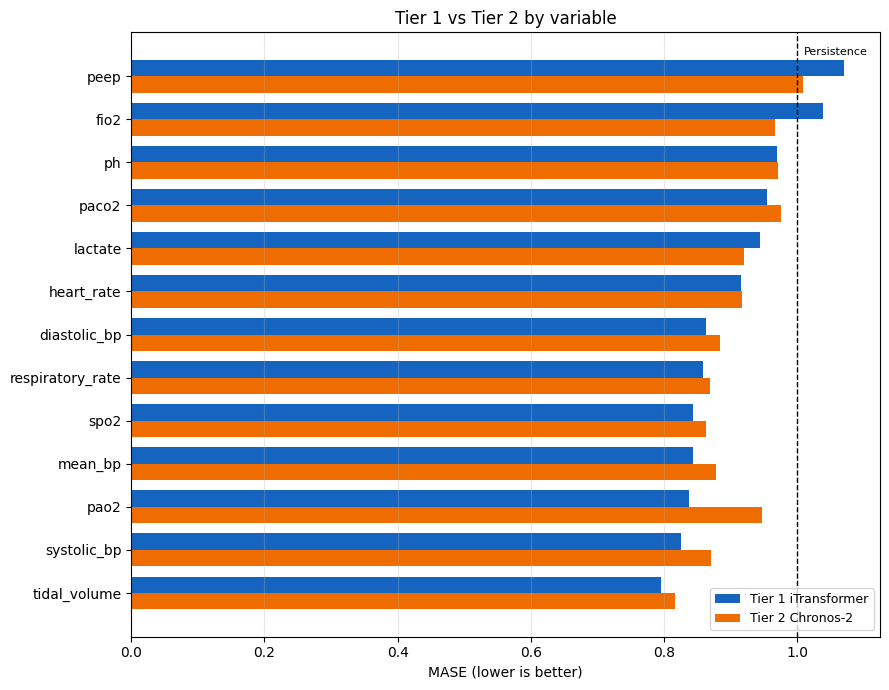

Saved: /content/drive/MyDrive/ventilator_weaning/figures/tier1_vs_tier2_mase.png


In [21]:
plot_df = comparison.dropna(subset=["tier1_MASE", "tier2_MASE"]).copy()
plot_df = plot_df.sort_values("tier1_MASE")

y = np.arange(len(plot_df))
height = 0.38

fig, ax = plt.subplots(figsize=(9, 7))

ax.barh(y + height / 2, plot_df["tier1_MASE"], height,
        color="#1565c0", label="Tier 1 iTransformer")
ax.barh(y - height / 2, plot_df["tier2_MASE"], height,
        color="#ef6c00", label="Tier 2 Chronos-2")

ax.axvline(1.0, color="black", linestyle="--", linewidth=1)
ax.text(1.01, len(plot_df) - 0.5, "Persistence", fontsize=8)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["variable"])
ax.set_xlabel("MASE (lower is better)")
ax.set_title("Tier 1 vs Tier 2 by variable")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "tier1_vs_tier2_mase.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {FIGURES_DIR / 'tier1_vs_tier2_mase.png'}")

**Interpretation**

Bars to the left of the dashed line beat persistence. Comparing the pairs shows which variables each approach handles better.

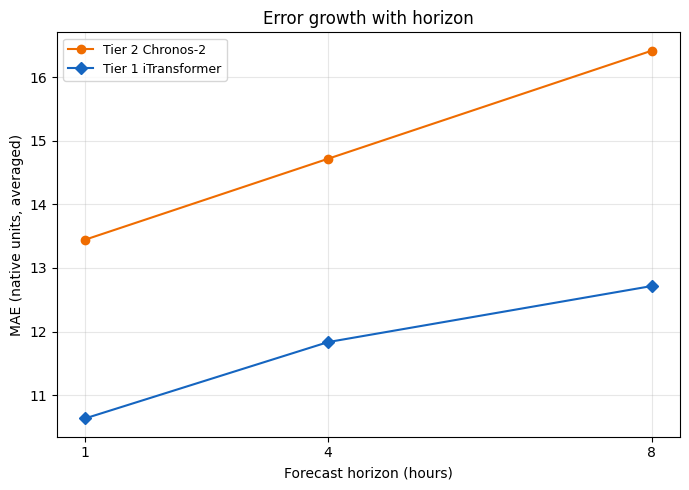

Saved: /content/drive/MyDrive/ventilator_weaning/figures/tier1_vs_tier2_horizon.png


In [22]:
t1_h = []
t2_h = []

for h_idx, h in enumerate(HORIZONS):
    m = test_tgt_mask[:, h_idx, :]
    t2_h.append(masked_mae_native(test_preds[:, h_idx, :], test_tgt[:, h_idx, :], m))
    t1_h.append(
        tier1_results[f"MAE_+{h}h"].mean()
        if f"MAE_+{h}h" in tier1_results.columns else np.nan
    )

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(HORIZONS, t2_h, marker="o", color="#ef6c00", label="Tier 2 Chronos-2")
ax.plot(HORIZONS, t1_h, marker="D", color="#1565c0", label="Tier 1 iTransformer")

ax.set_xlabel("Forecast horizon (hours)")
ax.set_ylabel("MAE (native units, averaged)")
ax.set_title("Error growth with horizon")
ax.set_xticks(HORIZONS)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "tier1_vs_tier2_horizon.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {FIGURES_DIR / 'tier1_vs_tier2_horizon.png'}")

**Interpretation**

Both lines should rise, because forecasting further ahead is harder. A steeper line means that model degrades faster over the eight hours.

### 16. Saving the artifacts

* Save the Tier 2 predictions so later notebooks can reuse them.
* Save to a permanent folder, not the temporary Colab folder.
* Record the chosen settings alongside the predictions.

AI-assisted: saving Chronos-2 test predictions, targets and run config to Drive for cross-notebook comparison, generated with Claude Opus 4.8 and verified by the author.

In [23]:
np.savez_compressed(
    TIER2_PRED_PATH,
    preds_native=test_preds,
    targets_native=test_tgt,
    target_mask=test_tgt_mask,
    persistence=test_persist,
    visit_ids=visit_ids[test_mask],
)

run_config = {
    "model": MODEL_NAME,
    "context_hours": BEST_CONTEXT,
    "mask_passed": BEST_USE_MASK,
    "horizons": HORIZONS,
    "overall_test_MASE": float(mase_all),
    "matched_48h_MASE": float(mase_matched),
    "n_test_windows": int(test_mask.sum()),
    "n_test_patients": int(len(np.unique(visit_ids[test_mask]))),
}

with open(TIER2_CONFIG_PATH, "w") as f:
    json.dump(run_config, f, indent=2)

# Read back to confirm the files saved
check = np.load(TIER2_PRED_PATH)
assert check["preds_native"].shape == test_preds.shape, "Saved predictions do not match."

print("Saved predictions and run config to Drive.")
print(json.dumps(run_config, indent=2))

Saved predictions and run config to Drive.
{
  "model": "amazon/chronos-2",
  "context_hours": 24,
  "mask_passed": true,
  "horizons": [
    1,
    4,
    8
  ],
  "overall_test_MASE": 0.8412628332408744,
  "matched_48h_MASE": 0.8410310578632672,
  "n_test_windows": 1149,
  "n_test_patients": 243
}


**Interpretation**

The predictions are stored on Drive so Tier 3 can be compared without re-running
Chronos-2.

### 17. Notebook summary

`### 19. Notebook summary`

Chronos-2 achieved a pooled MASE of 0.841 vs iTransformer's 0.819 — both beat persistence, iTransformer wins overall (p = 0.0013). Chronos-2 wins on FiO2, PEEP and lactate; iTransformer wins on the remaining 10 variables.